# WP5 · 03 — Exposure contrast, and Figure F2

**Work package:** WP5 / MAUP–exposure sensitivity · plan `docs/maup_sensitivity_and_spatial_cv_plan.md` §3.2
**Owner:** Geospatial Lead · **Country:** Sri Lanka · **Variables:** precipitation, temperature (t2m min/mean/max), RH

## What this notebook is, and — more important — what it is not

The plan bundles §3.2 (*exposure contrast, Figure F2*) and §3.3 (*decision-sensitivity re-run,
Figure F7*) into one line of work, and `notebooks_wp45/README.md` inherited that bundling: it lists
`wp5_03` as blocked behind "the fitted model (§8 blocker)".

**Half of that is wrong.** §3.3 needs the fitted model — it asks whether a *decision* flips. §3.2
does not: it asks how far the exposure *itself* moves when only its construction changes, and every
input to that question is already built and frozen on this machine. This notebook is the §3.2 half,
and it is complete. The §3.3 half stays blocked and nothing here anticipates its answer.

So: **this notebook measures displacement, not consequence.** No number below is a net benefit, an
alert count, or a decision flip. Read every "moves by X" as "the exposure a model would be fed
differs by X", never as "the model's output differs by X".

## The three rungs, and what each one changes

| build | mask | weights | temperature field | in this notebook |
|---|---|---|---|---|
| **A** (frozen build's construction) | `all_touched` | area | raw ERA5 / CHIRPS | emulated as `a_alltouched` for the mask decomposition |
| **A′** | fractional overlap | area | raw | the honest baseline arm |
| **B** | fractional overlap | **population** | raw | `wp5_01`, `wp5_02` |
| **C** | fractional overlap | population | **lapse-corrected to the elevation people live at** | `wp5_04` |

A′→B is a **re-weighting**: the same field, read at the places people are. B→C is a **correction to
the field itself**. §7 keeps them apart, and §9 shows why conflating them would overstate the MAUP
result by about half.

## Inputs — all frozen upstream, nothing rebuilt here

Ponytail rung 2: the exposure tables exist, are QC-passed, and are row-aligned by construction. This
notebook reads them and does not recompute a single weighted mean. §2 asserts that alignment rather
than assuming it.

## 1 · Setup, and the style block

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patheffects import withStroke
from scipy.stats import spearmanr, pearsonr

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
QUAR = REPO / "data_quarantine" / "wp5_exposure"
FIGS = REPO / "Manuscript_Figures" / "wp5"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"
FIGS.mkdir(parents=True, exist_ok=True)

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
SEED  = prov0["seed"]
CRS_DISPLAY = prov0["crs_display"]          # EPSG:32644 — the frame every M6/WP5 map uses

print("figure dir  :", FIGS.relative_to(REPO))
print("display CRS :", CRS_DISPLAY)
print("seed        :", SEED)

figure dir  : Manuscript_Figures/wp5
display CRS : EPSG:32644
seed        : 20260612


The style block is **ported verbatim from `notebooks/08_figures.ipynb`**, not rewritten. That is the
whole point of having one: a figure set drifts the moment a second copy of the rules exists. The only
addition is the categorical assignment for *this* figure's classes — the two ladder rungs, and the
two components B→C decomposes into.

In [2]:
MM = 1 / 25.4
W_SINGLE, W_DOUBLE = 89 * MM, 183 * MM      # journal column widths

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,          # TrueType — publishers reject Type 3
    "font.family": "sans-serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.2,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})

# One colour per ladder rung, fixed order, never cycled — Okabe-Ito, as notebook 08.
# Identity is ALSO carried by hatch, so the panels survive greyscale.
STEP = {
    "AB": dict(color="#0072B2", hatch="",    label="A′ → B  population weighting"),
    "BC": dict(color="#D55E00", hatch="///", label="B → C  lapse correction"),
}
# The two components B->C decomposes into (section 9). Distinct pair, not reused from STEP.
PART = {
    "orog": dict(color="#CC79A7", hatch="",    label="orography deficit (not MAUP)"),
    "sub":  dict(color="#009E73", hatch="///", label="sub-grid placement (MAUP)"),
}
# Diverging maps, midpoint pinned at zero. Sequential/rainbow would be wrong here: the
# sign of a displacement is the thing a reader must be able to read off the map.
CMAP = {"precip": "BrBG", "temp": "RdBu_r"}
HALO = [withStroke(linewidth=1.6, foreground="white")]

print("column widths: %.2f in single, %.2f in double" % (W_SINGLE, W_DOUBLE))
for k, v in STEP.items():
    print(f"  {k}  {v['color']}  hatch='{v['hatch']}'  {v['label']}")

column widths: 3.50 in single, 7.20 in double
  AB  #0072B2  hatch=''  A′ → B  population weighting
  BC  #D55E00  hatch='///'  B → C  lapse correction


## 2 · Load the frozen tables, and prove they are the same rows

Three tables, built by three different notebooks on three different days. Every contrast below is a
column subtraction, which is only meaningful if the rows line up. Assert it — do not eyeball the row
counts and move on.

The Build C table also carries its own copies of the `a_frac` and `b_pop` arms, rebuilt through an
independent code path in `wp5_04`. That gives a free cross-check that the two temperature notebooks
agree, so §2.2 takes it.

In [3]:
pr = pd.read_csv(QUAR / "wp5_precip_exposure_twin_srilanka_v1.csv")
tc = pd.read_csv(QUAR / "wp5_buildC_temp_exposure_srilanka_v1.csv")
te = pd.read_csv(QUAR / "wp5_temp_exposure_twin_srilanka_v1.csv")
dz = pd.read_csv(QUAR / "wp5_buildC_elevation_correction_srilanka.csv")

KEY = ["geometry_id", "rdhs_name", "iso_year", "iso_week"]
for name, d in [("precip twin", pr), ("temp twin", te), ("build C", tc)]:
    print(f"{name:12s} {str(d.shape):>12s}  districts {d.rdhs_name.nunique():3d}  "
          f"weeks {d.groupby(['iso_year','iso_week']).ngroups}")
print(f"{'elevation':12s} {str(dz.shape):>12s}")

precip twin   (10842, 16)  districts  26  weeks 417
temp twin     (10842, 32)  districts  26  weeks 417
build C       (10842, 37)  districts  26  weeks 417
elevation         (26, 7)


In [4]:
base = pr[KEY].reset_index(drop=True)
for name, d in [("temp twin", te), ("build C", tc)]:
    assert base.equals(d[KEY].reset_index(drop=True)), f"{name} rows do not align with the precip twin"
    print(f"row alignment precip twin vs {name:10s} : identical on {KEY}")

N_ROWS, N_UNITS = len(pr), pr.rdhs_name.nunique()
N_WEEKS = N_ROWS // N_UNITS
assert N_ROWS == N_UNITS * N_WEEKS == 10_842
print(f"\nthe panel: {N_UNITS} districts x {N_WEEKS} ISO weeks = {N_ROWS:,} district-weeks")

row alignment precip twin vs temp twin  : identical on ['geometry_id', 'rdhs_name', 'iso_year', 'iso_week']
row alignment precip twin vs build C    : identical on ['geometry_id', 'rdhs_name', 'iso_year', 'iso_week']

the panel: 26 districts x 417 ISO weeks = 10,842 district-weeks


### 2.1 · The two temperature notebooks must agree on the arms they share

In [5]:
for v in ["t2m_mean_c", "t2m_min_c", "t2m_max_c", "d2m_mean_c", "rh_mean_percent"]:
    row = []
    for arm in ["a_frac", "b_pop"]:
        row.append((tc[f"{v}_{arm}"] - te[f"{v}_{arm}"]).abs().max())
    print(f"  max|buildC - twin|  {v:16s}  a_frac {row[0]:.2e}   b_pop {row[1]:.2e}")

worst = max((tc[f"{v}_{a}"] - te[f"{v}_{a}"]).abs().max()
            for v in ["t2m_mean_c", "t2m_min_c", "t2m_max_c", "d2m_mean_c"] for a in ["a_frac", "b_pop"])
assert worst == 0.0, "the temperature arms disagree between wp5_02 and wp5_04"
print(f"\ntemperature arms agree exactly (max |diff| = {worst}).")
print("RH differs at ~1e-05 pp — wp5_04 recomputes it per cell per hour rather than reloading it;")
print("that is float32 accumulation order, not a disagreement.")

  max|buildC - twin|  t2m_mean_c        a_frac 0.00e+00   b_pop 0.00e+00
  max|buildC - twin|  t2m_min_c         a_frac 0.00e+00   b_pop 0.00e+00
  max|buildC - twin|  t2m_max_c         a_frac 0.00e+00   b_pop 0.00e+00
  max|buildC - twin|  d2m_mean_c        a_frac 0.00e+00   b_pop 0.00e+00
  max|buildC - twin|  rh_mean_percent   a_frac 9.11e-06   b_pop 1.65e-05

temperature arms agree exactly (max |diff| = 0.0).
RH differs at ~1e-05 pp — wp5_04 recomputes it per cell per hour rather than reloading it;
that is float32 accumulation order, not a disagreement.


## 3 · The contrasts, defined once

Three differences, and it matters which is which:

- `d_mask` — `all_touched` → fractional overlap. Which cells the district is allowed to see.
  **Not** part of the A′→B ladder; it is the frozen build's mask, isolated so it can be subtracted out.
- `d_weight` — area → population weights, on the fractional mask. **This is A′→B.**
- `bc_*` — Build B → Build C. The field itself, corrected from ERA5's orography to the elevation
  the population actually occupies.

(`d_total` in the precipitation file is the frozen table's own mask + weight sum; it is not used here,
because the two steps have to stay separable.)

Precipitation has no `d_lapse` rung, and §10 says why that is a property of the data, not an omission.

In [6]:
pr["d_mask"]   = pr.precip_sum_mm_a_frac - pr.precip_sum_mm_a_alltouched
pr["d_weight"] = pr.precip_sum_mm_b_pop  - pr.precip_sum_mm_a_frac

TVARS = ["t2m_min_c", "t2m_mean_c", "t2m_max_c", "d2m_mean_c", "rh_mean_percent"]
for v in TVARS:
    tc[f"ab_{v}"] = tc[f"{v}_b_pop"]  - tc[f"{v}_a_frac"]
    tc[f"bc_{v}"] = tc[f"{v}_c_pop"]  - tc[f"{v}_b_pop"]

print("precipitation contrasts :", [c for c in pr.columns if c.startswith("d_")])
print("temperature contrasts   :", [c for c in tc.columns if c.startswith(("ab_", "bc_"))])
print(f"\nevery contrast is a vector of {N_ROWS:,} district-weeks")

precipitation contrasts : ['d_mask', 'd_weight', 'd_total']
temperature contrasts   : ['ab_t2m_min_c', 'bc_t2m_min_c', 'ab_t2m_mean_c', 'bc_t2m_mean_c', 'ab_t2m_max_c', 'bc_t2m_max_c', 'ab_d2m_mean_c', 'bc_d2m_mean_c', 'ab_rh_mean_percent', 'bc_rh_mean_percent']

every contrast is a vector of 10,842 district-weeks


## 4 · National summary — §3.2's first bullet

Two normalisations, and neither alone is honest.

The **mean signed** displacement is what a bias argument wants, and it is small — the weights
redistribute, so gains and losses partly cancel across districts. The **mean absolute** displacement
is what a decision argument wants: a model does not care that Colombo's loss offsets Puttalam's gain,
it sees each district's own number.

For precipitation the percentage is taken as *ratio of means*, never as the mean of per-row ratios —
a dry district-week has A′ ≈ 0 and the ratio explodes. `wp5_01` §11 makes the same choice.

In [7]:
def summarise(s, unit, denom=None):
    out = {"mean": s.mean(), "mean|d|": s.abs().mean(), "sd": s.std(),
           "p05": s.quantile(.05), "p95": s.quantile(.95), "max|d|": s.abs().max()}
    if denom is not None:
        out["mean|d| as % of mean"] = 100 * s.abs().mean() / denom
    return pd.Series(out, name=unit)


mean_rain = pr.precip_sum_mm_a_frac.mean()
nat = pd.DataFrame([
    summarise(pr.d_mask,   "precip: A(all_touched) → A′ [mm/wk]", mean_rain),
    summarise(pr.d_weight, "precip: A′ → B [mm/wk]",              mean_rain),
] + [summarise(tc[f"ab_{v}"], f"temp: A′ → B  {v} [{'pp' if 'rh' in v else 'degC'}]") for v in TVARS]
  + [summarise(tc[f"bc_{v}"], f"temp: B → C  {v} [{'pp' if 'rh' in v else 'degC'}]") for v in TVARS])

print(f"mean weekly rainfall on the A′ arm: {mean_rain:.2f} mm\n")
print(nat.round(3).to_string())

mean weekly rainfall on the A′ arm: 42.94 mm

                                      mean  mean|d|     sd     p05    p95  max|d|  mean|d| as % of mean
precip: A(all_touched) → A′ [mm/wk]  0.087    0.763  1.257  -1.681  2.072  13.457                 1.776
precip: A′ → B [mm/wk]              -0.748    3.399  5.716 -10.155  6.978  72.586                 7.915
temp: A′ → B  t2m_min_c [degC]       0.090    0.316  0.407  -0.616  0.770   2.337                   NaN
temp: A′ → B  t2m_mean_c [degC]     -0.040    0.205  0.279  -0.596  0.329   1.164                   NaN
temp: A′ → B  t2m_max_c [degC]      -0.243    0.387  0.487  -1.200  0.392   2.764                   NaN
temp: A′ → B  d2m_mean_c [degC]     -0.005    0.136  0.197  -0.362  0.238   1.176                   NaN
temp: A′ → B  rh_mean_percent [pp]   0.080    0.769  1.077  -1.392  2.285   6.286                   NaN
temp: B → C  t2m_min_c [degC]        0.034    0.306  0.548  -1.333  0.861   1.917                   NaN
temp: B → C  t2m_m

Three things to read off that table before any figure.

1. **The mask is not the story; the weights are.** `all_touched` → fractional overlap moves 1.8% of
   mean rainfall. Area → population moves 7.9%, four times as far. What you weight *by* matters more
   than which cells you admit — and it is the frozen build's *weighting*, not its mask, that WP5 is
   really testing.
2. **Population weighting hits the extremes harder than the mean.** `t2m_max` moves 0.387 °C on
   average against 0.205 °C for `t2m_mean`, and up to 2.76 °C in a single district-week. A model
   driven by a thermal threshold feels roughly twice what a model driven by weekly mean temperature
   feels.
3. **The lapse correction moves all three temperature statistics by exactly the same amount.** That
   is not a coincidence and §8 turns it into a structural claim.

## 5 · Per district — §3.2's second bullet, and the deliverable

In [8]:
per = pd.DataFrame({
    "precip_mean_mm":  pr.groupby("rdhs_name").precip_sum_mm_a_frac.mean(),
    "precip_d_mask":   pr.groupby("rdhs_name").d_mask.mean(),
    "precip_ab":       pr.groupby("rdhs_name").d_weight.mean(),
    "precip_ab_sd":    pr.groupby("rdhs_name").d_weight.std(),
    "temp_mean_c":     tc.groupby("rdhs_name").t2m_mean_c_a_frac.mean(),
    "temp_ab":         tc.groupby("rdhs_name").ab_t2m_mean_c.mean(),
    "temp_ab_sd":      tc.groupby("rdhs_name").ab_t2m_mean_c.std(),
    "temp_ab_max":     tc.groupby("rdhs_name").ab_t2m_max_c.mean(),
    "temp_bc":         tc.groupby("rdhs_name").bc_t2m_mean_c.mean(),
    "temp_bc_sd":      tc.groupby("rdhs_name").bc_t2m_mean_c.std(),
    "rh_ab_pp":        tc.groupby("rdhs_name").ab_rh_mean_percent.mean(),
    "rh_bc_pp_td15":   tc.groupby("rdhs_name").bc_rh_mean_percent.mean(),
}).join(dz.set_index("rdhs_name")[["dz_pop", "dz_area", "dT_orog", "dT_subgrid"]])
per["precip_ab_pct"] = 100 * per.precip_ab.abs() / per.precip_mean_mm

print(per[["precip_ab", "precip_ab_pct", "temp_ab", "temp_bc", "rh_ab_pp"]]
      .sort_values("temp_bc").round(3).to_string())
print("\nmean |per-district| :",
      {k: round(v, 3) for k, v in per[["precip_ab", "temp_ab", "temp_bc"]].abs().mean().items()})

              precip_ab  precip_ab_pct  temp_ab  temp_bc  rh_ab_pp
rdhs_name                                                         
Nuwara Eliya     -0.298          0.557   -0.199   -1.917     0.487
Badulla          -0.840          1.880   -0.856   -1.333     0.864
Matale           -0.292          0.688   -0.189   -0.212     0.770
Vavuniya         -1.409          4.517   -0.051   -0.044    -0.043
Jaffna            1.064          4.302   -0.021   -0.034     0.163
Killinochchi      0.088          0.369   -0.025    0.008    -0.362
Mullaitivu        0.817          2.728   -0.057    0.013    -0.065
Anuradhapura     -0.951          3.163   -0.124    0.025     0.279
Puttalam          4.374         15.018   -0.050    0.048     0.446
Trincomalee      -0.028          0.088   -0.040    0.062    -0.269
Mannar           -2.453          9.434   -0.099    0.062     0.470
Batticaloa       -1.992          6.254    0.032    0.070     0.351
Polonnaruwa      -0.353          0.940    0.066    0.075    -0

**The per-district mean of |A′→B| for temperature (0.171 °C) is smaller than the district-week mean
(0.205 °C).** That gap is not an inconsistency — it is the week-to-week component. A re-weighting
reads a spatially varying field at different places, so its displacement varies as the field does;
averaging over weeks first cancels part of it. §8 shows the lapse correction has no such component at
all, which is why its two numbers are identical.

In [9]:
n_big_t  = int((per.temp_ab.abs()  >= 0.25).sum())
n_big_c  = int((per.temp_bc.abs()  >= 0.25).sum())
n_big_p  = int((per.precip_ab_pct  >= 5.0).sum())
print(f"districts moving >= 0.25 degC under population weighting : {n_big_t:2d} of {N_UNITS}")
print(f"districts moving >= 0.25 degC under the lapse correction : {n_big_c:2d} of {N_UNITS}")
print(f"districts whose rainfall moves >= 5% of its own mean     : {n_big_p:2d} of {N_UNITS}")
print("\nlargest movers, each contrast ranked on its own:")
for col, lab, u in [("precip_ab", "precip A′→B", "mm/wk"), ("temp_ab", "temp A′→B", "degC"),
                    ("temp_bc", "temp B→C", "degC")]:
    top = per[col].reindex(per[col].abs().sort_values(ascending=False).index).head(5)
    print(f"  {lab:14s} " + "  ".join(f"{k} {v:+.2f}" for k, v in top.items()) + f"  [{u}]")

districts moving >= 0.25 degC under population weighting :  6 of 26
districts moving >= 0.25 degC under the lapse correction :  6 of 26
districts whose rainfall moves >= 5% of its own mean     :  9 of 26

largest movers, each contrast ranked on its own:
  precip A′→B    Colombo -7.30  Matara -4.80  Puttalam +4.37  Galle -3.17  Kegalle -3.11  [mm/wk]
  temp A′→B      Badulla -0.86  Moneragala -0.47  Colombo +0.34  Kalutara +0.33  Kandy -0.29  [degC]
  temp B→C       Nuwara Eliya -1.92  Badulla -1.33  Ratnapura +1.01  Kegalle +0.86  Moneragala +0.45  [degC]


## 6 · Do the two variables agree about where construction matters?

This is the question §3.2's per-variable bullet is really asking, and it has a practical consequence.
If the districts whose rainfall moves are the districts whose temperature moves, then "exposure
construction matters here" is a property of a *place* and one map summarises it. If they are
different districts, then it is a property of a *place and a variable*, and any single-variable
sensitivity check understates the problem.

In [10]:
r_signed = pearsonr(per.precip_ab, per.temp_ab)
r_abs    = spearmanr(per.precip_ab.abs(), per.temp_ab.abs())
r_steps  = spearmanr(per.temp_ab.abs(), per.temp_bc.abs())

print(f"precip A′→B  vs  temp A′→B   signed Pearson  r = {r_signed.statistic:+.3f}  (p = {r_signed.pvalue:.3f})")
print(f"                            |.| Spearman  rho = {r_abs.statistic:+.3f}  (p = {r_abs.pvalue:.3f})")
print(f"temp A′→B    vs  temp B→C     |.| Spearman  rho = {r_steps.statistic:+.3f}  (p = {r_steps.pvalue:.3f})")

top5 = {lab: set(per[c].abs().sort_values(ascending=False).head(5).index)
        for c, lab in [("precip_ab", "precip A′→B"), ("temp_ab", "temp A′→B"), ("temp_bc", "temp B→C")]}
print("\noverlap of the five largest movers:")
for a in top5:
    for b in top5:
        if a < b:
            print(f"  {a:14s} ∩ {b:14s} = {sorted(top5[a] & top5[b]) or 'none'}")

precip A′→B  vs  temp A′→B   signed Pearson  r = -0.389  (p = 0.050)
                            |.| Spearman  rho = +0.243  (p = 0.231)
temp A′→B    vs  temp B→C     |.| Spearman  rho = +0.579  (p = 0.002)

overlap of the five largest movers:
  precip A′→B    ∩ temp A′→B      = ['Colombo']
  precip A′→B    ∩ temp B→C       = ['Kegalle']
  temp A′→B      ∩ temp B→C       = ['Badulla', 'Moneragala']


**The two variables do not agree.** Ranked by how far construction moves them, rainfall and
temperature share exactly one district in their top five, and the rank correlation of the absolute
displacements is not distinguishable from zero (ρ = 0.24, p = 0.23). The signed correlation is mildly
negative and only borderline (r = −0.39, p = 0.050) — districts that get *wetter* under population
weighting tend to get *cooler* — which is
what you expect when population sits inland and upslope of the areal centroid, but with n = 26 it is
a weak observation, not a mechanism.

**Consequence for the paper:** exposure construction is not a property of a district. A sensitivity
analysis that checks one variable and generalises will be wrong about which districts are exposed to
the choice. The two temperature *rungs* do correlate (ρ = 0.58, p = 0.002) — both are driven by
terrain — but even they rank their top districts differently: Nuwara Eliya is the largest B→C mover
and an unremarkable A′→B one.

## 7 · Where in the distribution each rung acts

Panel (d) of F2. Population weighting and the lapse correction do not act on the same part of the
temperature distribution, and a model form that is sensitive to one may be blind to the other.

In [11]:
stats = ["t2m_min_c", "t2m_mean_c", "t2m_max_c"]
shape = pd.DataFrame({
    "A′→B mean|d|": [tc[f"ab_{v}"].abs().mean() for v in stats],
    "B→C mean|d|":       [tc[f"bc_{v}"].abs().mean() for v in stats],
    "A′→B max|d|":  [tc[f"ab_{v}"].abs().max()  for v in stats],
    "B→C max|d|":        [tc[f"bc_{v}"].abs().max()  for v in stats],
}, index=["weekly minimum", "weekly mean", "weekly maximum"])
print(shape.round(3).to_string())
print("\nA′→B spread across the three statistics :",
      f"{shape['A′→B mean|d|'].max() - shape['A′→B mean|d|'].min():.3f} degC")
print("B→C  spread across the three statistics :",
      f"{shape['B→C mean|d|'].max() - shape['B→C mean|d|'].min():.3e} degC")

                A′→B mean|d|  B→C mean|d|  A′→B max|d|  B→C max|d|
weekly minimum         0.316        0.306        2.337       1.917
weekly mean            0.205        0.306        1.164       1.917
weekly maximum         0.387        0.306        2.764       1.917

A′→B spread across the three statistics : 0.183 degC
B→C  spread across the three statistics : 9.163e-08 degC


**Population weighting acts on the shape of the distribution; the lapse correction acts on its
location.** A′→B moves the weekly maximum nearly twice as far as the weekly mean (0.387 vs 0.205 °C),
because the extremes are where cells disagree most and re-weighting therefore has most to move.
B→C moves all three by an identical 0.306 °C, because it subtracts one number.

## 8 · Which parts of Build C are a pure per-district offset — and which are not

F2's panel (d) and its caption both rest on a structural claim from `wp5_04` §9: the lapse correction
carries no time index, so Build C is Build B plus a constant per-district offset. It is re-asserted
here rather than cited, because a figure should not depend on a number in another notebook.

**Re-asserting it narrows it.** The memo posted to PR #1 stated the claim for `t2m` *and* `d2m`. Only
`t2m` survives the check below; dewpoint does not, for a reason that is visible in one line of
`wp5_04`'s build code.

In [12]:
spread = pd.DataFrame({
    "within-district sd": [tc.groupby("rdhs_name")[f"bc_{v}"].std().max() for v in TVARS],
    "between-district |mean|": [tc.groupby("rdhs_name")[f"bc_{v}"].mean().abs().max() for v in TVARS],
}, index=TVARS)
print("Build B → C, over the 417 weeks:\n")
print(spread.round(4).to_string())

assert spread.loc["t2m_mean_c", "within-district sd"] < 1e-5, "the offset is not constant in time"
print("\nprecipitation A′→B, for contrast:")
w = pr.groupby("rdhs_name").d_weight.std()
print(f"  median within-district sd {w.median():.2f} mm/wk, max {w.max():.2f} — "
      f"against a mean |displacement| of {pr.d_weight.abs().mean():.2f} mm/wk")

Build B → C, over the 417 weeks:

                 within-district sd  between-district |mean|
t2m_min_c                    0.0000                   1.9172
t2m_mean_c                   0.0000                   1.9172
t2m_max_c                    0.0000                   1.9172
d2m_mean_c                   0.1588                   0.9036
rh_mean_percent              0.7084                   5.3727

precipitation A′→B, for contrast:
  median within-district sd 4.19 mm/wk, max 8.55 — against a mean |displacement| of 3.40 mm/wk


**Read the two columns together.** For temperature, B→C has essentially zero within-district
variation and up to 1.92 °C between districts: it is a district-level constant. For precipitation,
A′→B's within-district variation (median 4.19 mm/wk) is *larger* than its own mean displacement
(3.40 mm/wk) — the rainfall contrast is a genuinely time-varying signal, not a level shift.

**But `d2m` is not zero either — 0.159 °C.** A constant offset should have left it at machine
precision like `t2m`. §8.1 finds out why.

### 8.1 · Against the exact prediction, not against zero

The correction subtracts Γ·Δz from a field, so if nothing else intervened each B→C column would equal
−Γ·Δz *exactly*, with Γ = 6.5 °C/km for temperature and 1.5 °C/km for dewpoint, and Δz the
population-weighted elevation gap `wp5_04` already froze. That is a stronger test than "is the
variance small", and it is free.

In [13]:
GAMMA = {"t2m_min_c": 6.5e-3, "t2m_mean_c": 6.5e-3, "t2m_max_c": 6.5e-3, "d2m_mean_c": 1.5e-3}
obs  = pd.DataFrame({v: tc.groupby("rdhs_name")[f"bc_{v}"].mean() for v in GAMMA})
pred = pd.DataFrame({v: -g * per.dz_pop for v, g in GAMMA.items()})
dev  = (obs - pred).abs()

print("max |observed offset − (−Γ·Δz)| across the 26 districts:")
for v in GAMMA:
    print(f"  {v:12s} Γ = {1000*GAMMA[v]:.1f} degC/km   max deviation {dev[v].max():.3e} degC")

bad = dev.d2m_mean_c.sort_values(ascending=False)
sd_d2m = tc.groupby("rdhs_name").bc_d2m_mean_c.std()
print(f"\ndewpoint districts departing from the prediction by > 0.01 degC : {int((bad > 0.01).sum())} of {N_UNITS}")
print(f"dewpoint districts with ANY week-to-week variation (sd > 1e-3)  : {int((sd_d2m > 1e-3).sum())} of {N_UNITS}")
print(pd.DataFrame({"observed": obs.d2m_mean_c, "predicted": pred.d2m_mean_c,
                    "deviation": dev.d2m_mean_c, "elev gap Δz (m)": per.dz_pop,
                    "within-district sd": sd_d2m})
      .loc[bad.index[:6]].round(3).to_string())

max |observed offset − (−Γ·Δz)| across the 26 districts:
  t2m_min_c    Γ = 6.5 degC/km   max deviation 6.303e-07 degC
  t2m_mean_c   Γ = 6.5 degC/km   max deviation 6.026e-07 degC
  t2m_max_c    Γ = 6.5 degC/km   max deviation 6.851e-07 degC
  d2m_mean_c   Γ = 1.5 degC/km   max deviation 4.612e-01 degC

dewpoint districts departing from the prediction by > 0.01 degC : 3 of 26
dewpoint districts with ANY week-to-week variation (sd > 1e-3)  : 6 of 26
              observed  predicted  deviation  elev gap Δz (m)  within-district sd
rdhs_name                                                                        
Nuwara Eliya    -0.904     -0.442      0.461          294.954               0.149
Badulla         -0.549     -0.308      0.241          205.124               0.159
Kandy            0.079      0.094      0.015          -62.766               0.014
Matale          -0.057     -0.049      0.008           32.677               0.013
Matara           0.035      0.040      0.005          

**Temperature is exact; dewpoint is not.** `t2m` reproduces −6.5 °C/km × Δz to 6 × 10⁻⁷ °C in every
district. `d2m` departs from its own prediction by up to **0.46 °C** — materially in three districts and
detectably in six, and every one of them is a highland district.

The cause is the saturation guard in `wp5_04` §7.2 — `td = min(td − Γ_td·Δz, t − Γ_t·Δz)`. Because
temperature falls at 6.5 °C/km and dewpoint at 1.5, raising air by Δz closes the dew-point depression
by 5 °C/km × Δz — about 1.0 °C for Badulla's 205 m gap. Whenever the uncorrected air sits within that
of saturation the clip binds, and it binds in some hours and not others. The guard is physically
right — a dewpoint above the temperature is not a state air can be in — but it makes the dewpoint
correction **conditional on the weather rather than constant**.

**So the structural claim holds, with its scope tightened:**

| field | Build C = Build B + one constant per district? | absorbed by a district-relative model? |
|---|---|---|
| `t2m` min / mean / max | **yes**, to 6 × 10⁻⁷ °C | **yes, exactly** |
| `d2m` | **no** — clip-bound in 3 highland districts (detectable in 6), sd ≤ 0.16 °C | no |
| RH | **no** — nonlinear in both inputs, sd ≤ 0.71 pp | no |
| DTR (max − min) | the offset cancels entirely | **invariant — Build C cannot move it at all** |

**What this pre-constrains about the blocked §3.3 re-run,** stated exactly as far as it goes and no
further: a model on district-relative *temperature* — anomalies, district fixed effects, per-district
standardisation — absorbs the offset exactly, so **Build C cannot flip an alert in such a model**, and
a Build C null there would be a fact about the parameterisation, not about terrain. A model on
absolute temperature or a fixed thermal threshold sees the full offset. A model carrying **humidity or
dewpoint** sees a residual that no district effect can absorb, largest in exactly the highland
districts where the correction matters most. And **a Build C null must never be reported as "terrain
does not matter"**.

This is why the ask to the PI needs a second question attached: *which model form do the §5.1
artifacts use?* The answer determines what §3.3 is capable of finding before it is run.

## 9 · Decomposing B→C — the part of it that is not MAUP

Panel (f). B→C is two effects added together, and only one of them belongs to WP5's argument:

- **The orography deficit.** ERA5 believes Sri Lanka peaks at 1,219 m; it reaches 2,524 m. Correcting
  that applies under **area** weighting too — it is an exposure-*quality* problem, not an
  exposure-*construction* one, and it would be there if nobody had ever mentioned MAUP.
- **Sub-grid population placement.** Within a cell, people do not sit at the cell's mean elevation.
  *This* is the MAUP component: it exists only because the areal unit is coarse and the population is
  unevenly placed inside it.

`wp5_04` emits both columns. Quoting their sum as a MAUP effect would overstate WP5 by about half.

In [14]:
dec = per[["dT_orog", "dT_subgrid", "temp_bc"]].copy()
dec["sum_check"] = (dec.dT_orog + dec.dT_subgrid - dec.temp_bc).abs()
assert dec.sum_check.max() < 1e-6, "the decomposition does not sum to B→C"

print(f"mean |orography deficit|        {dec.dT_orog.abs().mean():.3f} degC   <- not MAUP")
print(f"mean |sub-grid placement|       {dec.dT_subgrid.abs().mean():.3f} degC   <- MAUP")
print(f"mean |B→C| (their sum)          {dec.temp_bc.abs().mean():.3f} degC")
opp = dec[np.sign(dec.dT_orog) != np.sign(dec.dT_subgrid)]
print(f"\ndistricts where the two components have OPPOSITE signs: {len(opp)} of {N_UNITS}")
print(dec.loc[opp.temp_bc.abs().sort_values(ascending=False).index[:4],
              ["dT_orog", "dT_subgrid", "temp_bc"]].round(3).to_string())

mean |orography deficit|        0.223 degC   <- not MAUP
mean |sub-grid placement|       0.169 degC   <- MAUP
mean |B→C| (their sum)          0.306 degC

districts where the two components have OPPOSITE signs: 12 of 26
              dT_orog  dT_subgrid  temp_bc
rdhs_name                                 
Nuwara Eliya   -2.256       0.339   -1.917
Kandy          -0.354       0.762    0.408
Matale         -0.286       0.074   -0.212
Matara         -0.089       0.262    0.173


The components can oppose each other — Nuwara Eliya's orography term is −2.26 °C against a +0.34 °C
sub-grid term — so they are not merely a large effect and a small one in the same direction. **The
MAUP-attributable mean is 0.169 °C, against 0.205 °C for population weighting.** On this grid the two
genuinely MAUP rungs are of comparable size; the headline 0.306 °C is the larger number only because
it includes a reanalysis bias that a MAUP argument cannot claim.

## 10 · Relative humidity, and why precipitation has no Build C

Two things this figure deliberately does not put on its face.

**RH's Build C shift is a function of an assumption, not a measurement.** The dewpoint lapse rate is
a choice, and `wp5_04` §8.1 brackets it: at 0.0 °C/km (vapour pressure conserved) the national mean
shift is −0.34 pp with a district range of −5.02 to +6.34; at 6.5 °C/km (RH conserved by
construction) the whole effect vanishes, −0.17 to +0.09 pp. The 1.5 °C/km used sits between. **Report
the bracket; never the middle alone.** RH therefore stays out of F2's panels and goes into the
per-district table with its rate stamped in the column name.

**Precipitation has no lapse rung because there is nothing to correct against.** CHIRPS is an
observational product — thermal-infrared cold-cloud duration calibrated to gauges — not a model with
an internal orography that disagrees with the real one. There is no "elevation CHIRPS believes", so
there is no B→C analogue to build. The physical analogue would be orographic rainfall enhancement,
which is a downscaling *model*, not a bias correction, and building one would violate the study's
no-new-model rule. This is a property of the data, not a gap in the ladder.

In [15]:
RH_BRACKET = {"Td 0.0 degC/km (vapour pressure conserved)": (-0.34, -5.02, +6.34),
              "Td 1.5 degC/km (used in the frozen table)":  (-0.23, -3.88, +5.37),
              "Td 6.5 degC/km (RH conserved)":              (+0.00, -0.17, +0.09)}
print("Build C RH shift, as wp5_04 section 8.1 brackets it:\n")
for k, (m, lo, hi) in RH_BRACKET.items():
    print(f"  {k:<42s} mean {m:+.2f} pp | district range {lo:+.2f} .. {hi:+.2f} pp")
print("\nMeasured here on the frozen (Td 1.5) table:",
      f"mean |d| {tc.bc_rh_mean_percent.abs().mean():.3f} pp,",
      f"max |d| {tc.bc_rh_mean_percent.abs().max():.3f} pp")

Build C RH shift, as wp5_04 section 8.1 brackets it:

  Td 0.0 degC/km (vapour pressure conserved) mean -0.34 pp | district range -5.02 .. +6.34 pp
  Td 1.5 degC/km (used in the frozen table)  mean -0.23 pp | district range -3.88 .. +5.37 pp
  Td 6.5 degC/km (RH conserved)              mean +0.00 pp | district range -0.17 .. +0.09 pp

Measured here on the frozen (Td 1.5) table: mean |d| 1.032 pp, max |d| 7.167 pp


## 11 · The per-district deliverable

In [16]:
out = per.copy()
out.insert(0, "geometry_id", pr.groupby("rdhs_name").geometry_id.first())
out = out.rename(columns={
    "temp_ab": "temp_a2b_c", "temp_ab_sd": "temp_a2b_sd_c", "temp_ab_max": "temp_a2b_tmax_c",
    "temp_bc": "temp_b2c_c", "temp_bc_sd": "temp_b2c_sd_c",
    "precip_ab": "precip_a2b_mm", "precip_ab_sd": "precip_a2b_sd_mm",
    "precip_ab_pct": "precip_a2b_pct_of_mean", "precip_d_mask": "precip_mask_step_mm",
    "rh_ab_pp": "rh_a2b_pp", "rh_bc_pp_td15": "rh_b2c_pp_td_1p5",
    "dT_orog": "temp_b2c_orography_c", "dT_subgrid": "temp_b2c_subgrid_c",
    "dz_pop": "elev_pop_minus_era5_m", "dz_area": "elev_area_minus_era5_m"})

CONTRAST = QUAR / "wp5_exposure_contrast_srilanka_v1.csv"
out.round(6).to_csv(CONTRAST)
print("wrote", CONTRAST.name, out.shape)
print(out.columns.tolist())

wrote wp5_exposure_contrast_srilanka_v1.csv (26, 18)
['geometry_id', 'precip_mean_mm', 'precip_mask_step_mm', 'precip_a2b_mm', 'precip_a2b_sd_mm', 'temp_mean_c', 'temp_a2b_c', 'temp_a2b_sd_c', 'temp_a2b_tmax_c', 'temp_b2c_c', 'temp_b2c_sd_c', 'rh_a2b_pp', 'rh_b2c_pp_td_1p5', 'elev_pop_minus_era5_m', 'elev_area_minus_era5_m', 'temp_b2c_orography_c', 'temp_b2c_subgrid_c', 'precip_a2b_pct_of_mean']


## 12 · Figure F2

Six panels, one figure, double-column width. Maps carry *where*, the bar panels carry *how much* and
*in what way*.

The maps are diverging with the midpoint pinned at exactly zero — for a displacement, the sign is the
first thing a reader needs and a sequential ramp would hide it. Each map is scaled to its own
variable's range, because mm and °C cannot share a colourbar; the three largest movers are labelled
in-map so the numbers survive greyscale reproduction, where a diverging ramp collapses. Panels (d)
and (f) carry hatch as a second identity channel for the same reason.

In [17]:
rdhs = gpd.read_file(GEOM).to_crs(CRS_DISPLAY)
sha_geom = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
assert sha_geom == prov0["geometry_sha256_16"], "geometry differs from the M6 frame"
gm = rdhs.merge(per[["precip_ab", "temp_ab", "temp_bc"]], left_on="rdhs_name", right_index=True)
print("map frame:", CRS_DISPLAY, "| units", len(gm), "| geometry sha", sha_geom, "OK")

map frame: EPSG:32644 | units 26 | geometry sha 9e5e2c0a541ecac1 OK


wrote WP5_F2_exposure_contrast.pdf


wrote WP5_F2_exposure_contrast.png


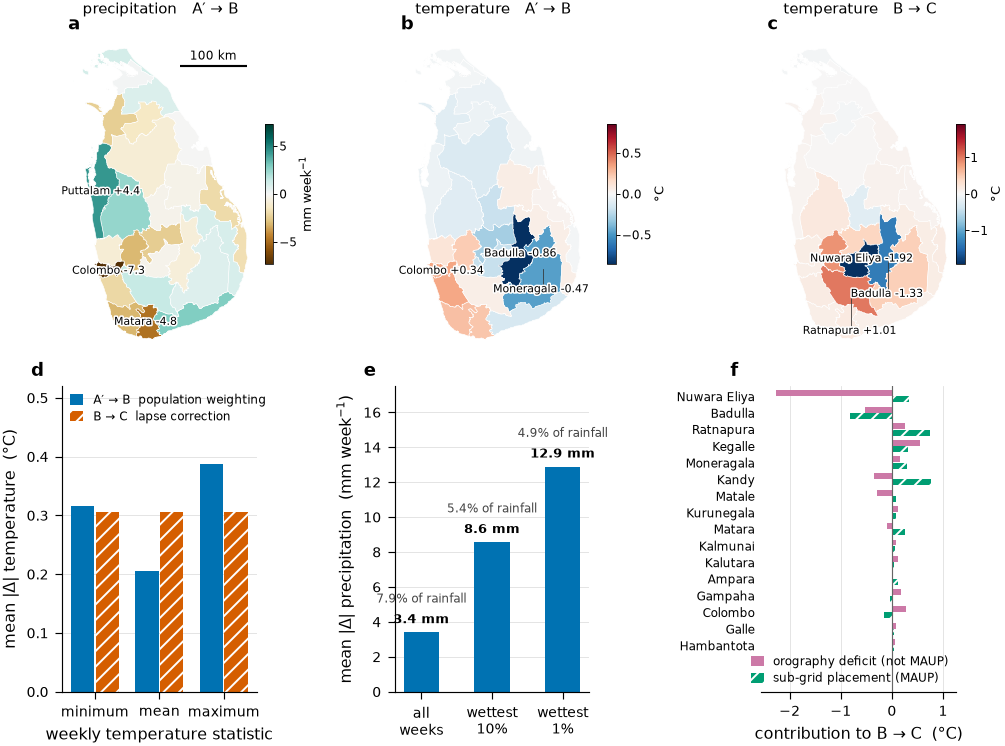

In [18]:
# One diverging choropleth: midpoint pinned at zero, largest movers labelled with leader lines.
def choro(ax, col, cmap, unit, fmt="{:+.2f}", n_label=3):
    v = gm[col]
    lim = float(np.abs(v).max())
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
    gm.plot(column=col, cmap=cmap, norm=norm, ax=ax, edgecolor="white", linewidth=0.3)
    ax.set_axis_off()
    cb = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                      fraction=0.045, pad=0.0, shrink=0.62, aspect=16)
    cb.set_label(unit, size=6.5, labelpad=1)
    cb.ax.tick_params(labelsize=6, width=0.5, length=2, pad=1)
    cb.outline.set_linewidth(0.4)
    placed = []
    for _, r in gm.reindex(v.abs().sort_values(ascending=False).index[:n_label]).iterrows():
        p = r.geometry.representative_point()
        x, y = p.x, p.y
        while any(abs(x - px) < 105_000 and abs(y - py) < 30_000 for px, py in placed):
            y -= 30_000
        placed.append((x, y))
        if y != p.y:                                   # label was moved — say where it belongs
            ax.plot([p.x, x], [p.y, y], color="#333333", lw=0.4, zorder=4)
        ax.annotate(f"{r.rdhs_name} {fmt.format(r[col])}", (x, y), fontsize=5.6, ha="center",
                    va="center", path_effects=HALO, zorder=5)


fig = plt.figure(figsize=(W_DOUBLE, 0.74 * W_DOUBLE), layout="constrained")
fig.get_layout_engine().set(w_pad=0.03, h_pad=0.02, wspace=0.03, hspace=0.02)
gs = fig.add_gridspec(2, 3, height_ratios=[1.05, 1.0])

axa, axb, axc = (fig.add_subplot(gs[0, i]) for i in range(3))
choro(axa, "precip_ab", CMAP["precip"], "mm week$^{-1}$", "{:+.1f}")
choro(axb, "temp_ab",   CMAP["temp"],   "°C")
choro(axc, "temp_bc",   CMAP["temp"],   "°C")
for ax, lab, sub in [(axa, "a", "precipitation   A′ → B"),
                     (axb, "b", "temperature   A′ → B"),
                     (axc, "c", "temperature   B → C")]:
    ax.set_title(sub, size=7.5, pad=2)
    ax.text(0.02, 1.00, lab, transform=ax.transAxes, size=9, weight="bold", va="bottom")

x0, x1 = axa.get_xlim(); y0, y1 = axa.get_ylim()
bx, by, L = x0 + 0.60 * (x1 - x0), y0 + 0.90 * (y1 - y0), 100_000
axa.plot([bx, bx + L], [by, by], color="black", lw=1.1, solid_capstyle="butt")
axa.text(bx + L / 2, by + 0.010 * (y1 - y0), "100 km", ha="center", va="bottom", size=6)

# (d) which part of the temperature distribution each rung moves
axd = fig.add_subplot(gs[1, 0])
xs = np.arange(3)
for off, vals, k in [(-0.19, shape["A′→B mean|d|"].values, "AB"),
                     (0.19,  shape["B→C mean|d|"].values,       "BC")]:
    axd.bar(xs + off, vals, 0.36, color=STEP[k]["color"], hatch=STEP[k]["hatch"],
            edgecolor="white", linewidth=0, label=STEP[k]["label"])
axd.set_xticks(xs, ["minimum", "mean", "maximum"])
axd.set_xlabel("weekly temperature statistic")
axd.set_ylabel("mean |Δ| temperature  (°C)")
axd.legend(frameon=False, loc="upper left", handlelength=1.1, handleheight=0.9,
           borderpad=0.1, labelspacing=0.3, fontsize=6.4)
axd.set_ylim(0, 0.52)
axd.grid(axis="y", color="#dddddd")
axd.set_axisbelow(True)

# (e) does the rainfall contrast survive into the weeks that would trigger an alert?
axe = fig.add_subplot(gs[1, 1])
q = pr.precip_sum_mm_a_frac
strata = [("all\nweeks", pr.index), ("wettest\n10%", pr.index[q >= q.quantile(.90)]),
          ("wettest\n1%", pr.index[q >= q.quantile(.99)])]
mm_v = [pr.loc[ix].d_weight.abs().mean() for _, ix in strata]
pct_v = [100 * pr.loc[ix].d_weight.abs().mean() / pr.loc[ix].precip_sum_mm_a_frac.mean()
         for _, ix in strata]
axe.bar(np.arange(3), mm_v, 0.5, color=STEP["AB"]["color"])
for i, (m, p) in enumerate(zip(mm_v, pct_v)):
    axe.text(i, m + 0.35, f"{m:.1f} mm", ha="center", va="bottom", size=6.8, weight="bold")
    axe.text(i, m + 1.55, f"{p:.1f}% of rainfall", ha="center", va="bottom", size=6.0,
             color="#444444")
axe.set_xticks(np.arange(3), [s for s, _ in strata])
axe.set_ylabel("mean |Δ| precipitation  (mm week$^{-1}$)")
axe.set_ylim(0, 17.5)
axe.grid(axis="y", color="#dddddd")
axe.set_axisbelow(True)

# (f) B->C split into the part that is MAUP and the part that is not
axf = fig.add_subplot(gs[1, 2])
d = per.reindex(per.temp_bc.abs().sort_values().index)
d = d[d.temp_bc.abs() >= 0.10]
yy = np.arange(len(d))
for off, col, k in [(0.19, "dT_orog", "orog"), (-0.19, "dT_subgrid", "sub")]:
    axf.barh(yy + off, d[col], 0.36, color=PART[k]["color"], hatch=PART[k]["hatch"],
             edgecolor="white", linewidth=0, label=PART[k]["label"])
axf.set_yticks(yy, d.index, size=6.2)
axf.set_ylim(-2.8, len(d) - 0.4)                  # blank rows so the legend clears the bars
axf.axvline(0, color="#666666", lw=0.6)
axf.set_xlabel("contribution to B → C  (°C)")
axf.set_xlim(-2.55, 1.25)
axf.legend(frameon=False, loc="lower right", handlelength=1.1, handleheight=0.9,
           borderpad=0.1, labelspacing=0.3, fontsize=6.0)
axf.grid(axis="x", color="#dddddd")
axf.set_axisbelow(True)
axf.spines["left"].set_visible(False)
axf.tick_params(axis="y", length=0)
for ax, lab in [(axd, "d"), (axe, "e"), (axf, "f")]:
    ax.text(-0.16, 1.02, lab, transform=ax.transAxes, size=9, weight="bold", va="bottom")

written = []
for ext, kw in [("pdf", {}), ("png", dict(dpi=600))]:
    p = FIGS / f"WP5_F2_exposure_contrast.{ext}"
    fig.savefig(p, **kw)
    written.append(p)
    print("wrote", p.name)
plt.show()

## 13 · The greyscale check, done rather than asserted

`figure-style` requires a greyscale pass. Two of the six panels use hatch as a second channel and
pass trivially. **The three maps do not, and saying so is the honest result** — a diverging ramp is
symmetric in luminance by design, so +1.9 °C and −1.9 °C print as the same grey. That is why the
largest movers are labelled numerically on the map face, and why the caption states the midpoint.

In [19]:
def luminance(rgb):
    f = lambda c: c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * f(rgb[0]) + 0.7152 * f(rgb[1]) + 0.0722 * f(rgb[2])


print("categorical classes — luminance separation:")
cats = {**{f"STEP.{k}": v["color"] for k, v in STEP.items()},
        **{f"PART.{k}": v["color"] for k, v in PART.items()}}
for k, hexc in cats.items():
    rgb = tuple(int(hexc[i:i + 2], 16) / 255 for i in (1, 3, 5))
    print(f"  {k:<10s} {hexc}  L = {luminance(rgb):.3f}")

print("\ndiverging maps — luminance at the two extremes and the midpoint:")
for name in set(CMAP.values()):
    cm = mpl.colormaps[name]
    lo, mid, hi = (luminance(cm(x)[:3]) for x in (0.0, 0.5, 1.0))
    print(f"  {name:8s} L(-max) {lo:.3f}   L(0) {mid:.3f}   L(+max) {hi:.3f}   "
          f"|L(-max) - L(+max)| = {abs(lo - hi):.3f}")
print("\nThe ends are near-identical in luminance: sign is NOT recoverable in greyscale from the")
print("ramp alone. Magnitude is (both ends are dark against a light midpoint), and the labelled")
print("extremes carry the sign. Stated in the caption rather than papered over.")

categorical classes — luminance separation:
  STEP.AB    #0072B2  L = 0.152
  STEP.BC    #D55E00  L = 0.222
  PART.orog  #CC79A7  L = 0.293
  PART.sub   #009E73  L = 0.257

diverging maps — luminance at the two extremes and the midpoint:
  RdBu_r   L(-max) 0.030   L(0) 0.926   L(+max) 0.030   |L(-max) - L(+max)| = 0.000
  BrBG     L(-max) 0.040   L(0) 0.910   L(+max) 0.034   |L(-max) - L(+max)| = 0.006

The ends are near-identical in luminance: sign is NOT recoverable in greyscale from the
ramp alone. Magnitude is (both ends are dark against a light midpoint), and the labelled
extremes carry the sign. Stated in the caption rather than papered over.


## 14 · Caption

In [20]:
caption = (
    "**Figure F2. Exposure construction moves district exposure, and moves it differently for "
    f"each variable.** Contrasts over {N_ROWS:,} district-weeks ({N_UNITS} RDHS x {N_WEEKS} ISO weeks, "
    "2018-2025). (a-c) District mean displacement, mapped; diverging scales with the midpoint at "
    f"exactly zero, each scaled to its own variable's range; frame {CRS_DISPLAY}; the three largest "
    "movers are labelled because a diverging ramp does not survive greyscale reproduction. "
    "(a) Precipitation under population weighting (A' -> B), mm per week. (b) Weekly mean temperature "
    "under population weighting, degC. (c) Weekly mean temperature under the lapse correction "
    "(B -> C), degC. (d) Mean absolute displacement of the weekly minimum, mean and maximum "
    "temperature: population weighting acts on the shape of the distribution and moves the maximum "
    "nearly twice as far as the mean, while the lapse correction is a single offset per district and "
    "therefore identical across all three statistics. (e) Rainfall displacement in the wet weeks that "
    "would trigger an alert; it grows in millimetres and shrinks as a share of rainfall. "
    "(f) B -> C separated into the ERA5 orography deficit, which applies under area weighting too and "
    "is not a MAUP effect, and sub-grid population placement, which is; districts with |B -> C| >= "
    "0.10 degC. Temperature is ERA5 0.25 deg (ERA5-Land 0.1 deg was unavailable), which attenuates the "
    "population-weighting contrast to 65.3% of its 0.1 deg value, so (b) and (d) are conservative "
    "floors. The figure reports displacement of exposure only; whether it changes a decision is "
    "plan section 3.3 and is not answered here."
)
print(caption)

**Figure F2. Exposure construction moves district exposure, and moves it differently for each variable.** Contrasts over 10,842 district-weeks (26 RDHS x 417 ISO weeks, 2018-2025). (a-c) District mean displacement, mapped; diverging scales with the midpoint at exactly zero, each scaled to its own variable's range; frame EPSG:32644; the three largest movers are labelled because a diverging ramp does not survive greyscale reproduction. (a) Precipitation under population weighting (A' -> B), mm per week. (b) Weekly mean temperature under population weighting, degC. (c) Weekly mean temperature under the lapse correction (B -> C), degC. (d) Mean absolute displacement of the weekly minimum, mean and maximum temperature: population weighting acts on the shape of the distribution and moves the maximum nearly twice as far as the mean, while the lapse correction is a single offset per district and therefore identical across all three statistics. (e) Rainfall displacement in the wet weeks that wo

## 15 · QC

In [21]:
checks = {
    "rows = 26 x 417": len(pr) == len(tc) == 10_842,
    "keys aligned across all three tables": base.equals(tc[KEY].reset_index(drop=True)),
    "temperature arms agree wp5_02 vs wp5_04": worst == 0.0,
    "decomposition sums to B->C": dec.sum_check.max() < 1e-6,
    "B->C constant in time (t2m)": spread.loc["t2m_mean_c", "within-district sd"] < 1e-5,
    "B->C NOT constant in time (RH)": spread.loc["rh_mean_percent", "within-district sd"] > 1e-3,
    "t2m B->C equals -6.5 degC/km x dz_pop": dev[["t2m_min_c", "t2m_mean_c", "t2m_max_c"]].max().max() < 1e-5,
    "d2m B->C does NOT (saturation clip binds)": dev.d2m_mean_c.max() > 0.1,
    "DTR is invariant under B->C": float((tc.bc_t2m_max_c - tc.bc_t2m_min_c).abs().max()) < 1e-5,
    "no NaN in any contrast": not (pr[["d_mask", "d_weight"]].isna().any().any()
                                   or tc[[f"ab_{v}" for v in TVARS] + [f"bc_{v}" for v in TVARS]].isna().any().any()),
    "A'->B max|d| exceeds the mean by >5x (precip)": pr.d_weight.abs().max() > 5 * pr.d_weight.abs().mean(),
    "per-district table covers every unit": len(out) == N_UNITS,
    "contrast CSV written": CONTRAST.exists(),
    "figure written as vector + raster": {p.suffix for p in written} == {".pdf", ".png"},
    "geometry matches the M6 frame": sha_geom == prov0["geometry_sha256_16"],
}
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(checks.values()), "QC failed"
print(f"\n{sum(checks.values())}/{len(checks)} checks pass")

  [PASS] rows = 26 x 417
  [PASS] keys aligned across all three tables
  [PASS] temperature arms agree wp5_02 vs wp5_04
  [PASS] decomposition sums to B->C
  [PASS] B->C constant in time (t2m)
  [PASS] B->C NOT constant in time (RH)
  [PASS] t2m B->C equals -6.5 degC/km x dz_pop
  [PASS] d2m B->C does NOT (saturation clip binds)
  [PASS] DTR is invariant under B->C
  [PASS] no NaN in any contrast
  [PASS] A'->B max|d| exceeds the mean by >5x (precip)
  [PASS] per-district table covers every unit
  [PASS] contrast CSV written
  [PASS] figure written as vector + raster
  [PASS] geometry matches the M6 frame

15/15 checks pass


## 16 · Provenance, and the staleness gate

`figure-style`'s pre-submission rule: a figure must be newer than the tables that produced it. Stale
figures beside updated numbers is the most common submission defect, so it is an assertion here, not
a checklist item.

In [22]:
SRC = ["wp5_precip_exposure_twin_srilanka_v1.csv", "wp5_temp_exposure_twin_srilanka_v1.csv",
       "wp5_buildC_temp_exposure_srilanka_v1.csv", "wp5_buildC_elevation_correction_srilanka.csv"]

prov = {
    "notebook": "wp5_03_exposure_contrast_and_F2",
    "work_package": "WP5", "plan_section": "3.2", "country": "sri_lanka",
    "scope": "exposure displacement only; plan section 3.3 (decision sensitivity, F7) is NOT answered here",
    "seed": SEED, "n_rows": int(N_ROWS), "n_units": int(N_UNITS), "n_weeks": int(N_WEEKS),
    "inputs": {n: hashlib.sha256((QUAR / n).read_bytes()).hexdigest()[:16] for n in SRC},
    "geometry_sha256_16": sha_geom, "crs_display": CRS_DISPLAY,
    "headline": {
        "precip_mask_step_mean_abs_mm": float(pr.d_mask.abs().mean()),
        "precip_a2b_mean_abs_mm": float(pr.d_weight.abs().mean()),
        "precip_a2b_pct_of_mean_rainfall": float(100 * pr.d_weight.abs().mean() / mean_rain),
        "temp_a2b_mean_abs_c": float(tc.ab_t2m_mean_c.abs().mean()),
        "temp_a2b_tmax_mean_abs_c": float(tc.ab_t2m_max_c.abs().mean()),
        "temp_b2c_mean_abs_c": float(tc.bc_t2m_mean_c.abs().mean()),
        "temp_b2c_orography_mean_abs_c": float(dec.dT_orog.abs().mean()),
        "temp_b2c_subgrid_mean_abs_c": float(dec.dT_subgrid.abs().mean()),
        "precip_vs_temp_rank_corr_abs": float(r_abs.statistic),
        "precip_vs_temp_rank_corr_p": float(r_abs.pvalue),
        "t2m_b2c_max_dev_from_linear_c": float(dev[["t2m_min_c", "t2m_mean_c", "t2m_max_c"]].max().max()),
        "d2m_b2c_max_dev_from_linear_c": float(dev.d2m_mean_c.max()),
    },
    "correction_to_prior_memo": (
        "PR #1 (comment 5287452143) stated Build C is a constant per-district offset for t2m AND d2m. "
        "It holds for t2m to 6e-07 degC; d2m departs by up to 0.46 degC (Nuwara Eliya; Badulla 0.24) because "
        "the saturation clip td = min(td - 1.5*dz, t - 6.5*dz) binds in some hours and not others. "
        "Consequence: a humidity- or dewpoint-carrying model sees a Build C residual that a district "
        "fixed effect cannot absorb."),
    "rh_bracket_pp": {k: {"mean": m, "min": lo, "max": hi} for k, (m, lo, hi) in RH_BRACKET.items()},
    "style": {"single_col_mm": 89, "double_col_mm": 183, "base_font_pt": 8, "min_font_pt": 5.6,
              "pdf_fonttype": 42, "raster_dpi": 600,
              "palette": {**{f"STEP.{k}": v["color"] for k, v in STEP.items()},
                          **{f"PART.{k}": v["color"] for k, v in PART.items()}},
              "palette_source": "Okabe-Ito, as notebooks/08_figures.ipynb",
              "diverging_maps": CMAP, "diverging_midpoint": 0.0,
              "identity_channels": ["colour", "hatch", "in-map numeric label"],
              "greyscale": "categorical panels pass via hatch; diverging maps do not encode sign in "
                           "luminance, mitigated by labelling the extremes"},
    "outputs": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:16] for p in written},
    "contrast_table": {CONTRAST.name: hashlib.sha256(CONTRAST.read_bytes()).hexdigest()[:16]},
    "caption": caption,
}
(QUAR / "wp5_03_provenance.json").write_text(json.dumps(prov, indent=2))

src_mtime = max((QUAR / n).stat().st_mtime for n in SRC)
stale = [p.name for p in written if p.stat().st_mtime < src_mtime]
assert not stale, f"stale figures: {stale} — regenerate before submission"
print("provenance written; figures are newer than every table that produced them")

provenance written; figures are newer than every table that produced them


## 17 · Recap — every number in one table

In [23]:
recap = pd.DataFrame([
    ("panel",   "rows", "26 RDHS x 417 ISO weeks", f"{N_ROWS:,}"),
    ("precip",  "mask step  A(all_touched)->A'", "mean |d|", f"{pr.d_mask.abs().mean():.2f} mm/wk ({100*pr.d_mask.abs().mean()/mean_rain:.1f}%)"),
    ("precip",  "A'->B  population weighting", "mean |d|", f"{pr.d_weight.abs().mean():.2f} mm/wk ({100*pr.d_weight.abs().mean()/mean_rain:.1f}%)"),
    ("precip",  "A'->B, wettest 10% of weeks", "mean |d|", f"{mm_v[1]:.2f} mm/wk ({pct_v[1]:.1f}%)"),
    ("precip",  "A'->B, wettest 1% of weeks",  "mean |d|", f"{mm_v[2]:.2f} mm/wk ({pct_v[2]:.1f}%)"),
    ("precip",  "A'->B largest district",      "mean",     f"Colombo {per.precip_ab.min():+.2f} mm/wk"),
    ("temp",    "A'->B  weekly mean",          "mean |d|", f"{tc.ab_t2m_mean_c.abs().mean():.3f} degC"),
    ("temp",    "A'->B  weekly maximum",       "mean |d|", f"{tc.ab_t2m_max_c.abs().mean():.3f} degC"),
    ("temp",    "B->C   all three statistics", "mean |d|", f"{tc.bc_t2m_mean_c.abs().mean():.3f} degC"),
    ("temp",    "B->C   orography deficit",    "mean |d|", f"{dec.dT_orog.abs().mean():.3f} degC  (not MAUP)"),
    ("temp",    "B->C   sub-grid placement",   "mean |d|", f"{dec.dT_subgrid.abs().mean():.3f} degC  (MAUP)"),
    ("temp",    "B->C within-district sd",     "max",      f"{spread.loc['t2m_mean_c','within-district sd']:.1e} degC  (a pure offset)"),
    ("dewpoint","B->C vs the exact -1.5 degC/km prediction", "max dev", f"{dev.d2m_mean_c.max():.3f} degC  (saturation clip, highland districts)"),
    ("RH",      "B->C  (Td 1.5 degC/km)",      "mean |d|", f"{tc.bc_rh_mean_percent.abs().mean():.3f} pp  — bracketed, see section 10"),
    ("cross",   "|precip A'->B| vs |temp A'->B|", "Spearman", f"rho = {r_abs.statistic:+.3f} (p = {r_abs.pvalue:.2f})"),
    ("cross",   "|temp A'->B| vs |temp B->C|",    "Spearman", f"rho = {r_steps.statistic:+.3f} (p = {r_steps.pvalue:.3f})"),
], columns=["variable", "contrast", "statistic", "value"])
print(recap.to_string(index=False))

variable                                  contrast               statistic                                             value
   panel                                      rows 26 RDHS x 417 ISO weeks                                            10,842
  precip             mask step  A(all_touched)->A'                mean |d|                                 0.76 mm/wk (1.8%)
  precip               A'->B  population weighting                mean |d|                                 3.40 mm/wk (7.9%)
  precip               A'->B, wettest 10% of weeks                mean |d|                                 8.56 mm/wk (5.4%)
  precip                A'->B, wettest 1% of weeks                mean |d|                                12.89 mm/wk (4.9%)
  precip                    A'->B largest district                    mean                               Colombo -7.30 mm/wk
    temp                        A'->B  weekly mean                mean |d|                                        0.205 degC


---

## What this establishes, and what it does not

**Establishes.**

1. **Exposure construction moves exposure, on every variable measured.** Rainfall by 3.40 mm/wk
   (7.9% of its mean), weekly mean temperature by 0.205 °C, weekly maximum temperature by 0.387 °C,
   the lapse correction by a further 0.306 °C. WP5's honest-null clause (§3.4) fires on neither
   variable at the exposure stage.
2. **The mask is a footnote; the weights are the result.** 1.8% against 7.9%. The construction choice
   that matters is what you weight by, not which cells you admit.
3. **Exposure construction is not a property of a district.** Rainfall and temperature disagree about
   where it matters (ρ = 0.24, p = 0.23; one district shared between their top fives). A
   single-variable sensitivity check will misidentify the exposed districts.
4. **The two rungs act on different parts of the distribution.** Population weighting moves the weekly
   maximum ~2× the mean; the lapse correction moves every statistic identically because it is one
   offset per district.
5. **Only 0.169 of the 0.306 °C B→C effect is attributable to MAUP.** The rest is ERA5's orography
   deficit, which applies under area weighting too. The combined number belongs to an
   exposure-*quality* argument, not this one.
6. **In the weeks that would trigger an alert, the rainfall contrast grows in absolute terms and
   shrinks in relative terms** — 12.9 mm and 4.9% in the wettest 1% of district-weeks. A decision
   analysis feels the millimetres.
7. **A correction to a claim already sent.** The PR #1 memo said Build C is a constant per-district
   offset "for `t2m` and `d2m`". It holds for `t2m` to 6 × 10⁻⁷ °C and **not for `d2m`**: the
   physically necessary saturation clip binds in the highland districts and makes the dewpoint
   correction weather-dependent, up to 0.46 °C away from the constant it was assumed to be. The
   consequence runs the useful way — a humidity-carrying model sees a Build C residual that a
   district effect cannot absorb, so §3.3 has more to find there than the memo implied.

**Does not establish.**

- **Nothing about decisions.** No net benefit, no alert count, no flip. That is §3.3, and it is
  blocked on the §5.1 design matrices along with §4, §8 and WP4's evaluation half.
- **Nothing about which highland districts warm.** Temperature runs on ERA5 0.25°, which sees 65.3%
  of the population-weighting displacement against 91.7% at 0.1°; every temperature number is a
  conservative floor and the per-district ordering within panel (b) is not defensible on its own.
- **Nothing measured about RH's Build C shift.** It is bracketed by an assumed dewpoint lapse rate
  and vanishes at one end of that bracket.
- **No claim that B→C would move a district-relative model on temperature.** §8.1 shows it cannot, by
  construction — and equally, no claim that it would leave a humidity-carrying model alone.

**What it changes about the next step.** The ask to the PI should now carry a second question
alongside the §5.1 artifact request: **which model form do those artifacts use?** If the reference
model is district-relative, §3.3 can only ever return a Build C null, and that null would be a
property of the model's parameterisation rather than of terrain. Better to know before the re-run
than to explain it afterwards.